# Fase 1. Exploración de bases de datos

Se revisan tres bases colombianas, de dos tipos (tabular y audio). De cada una se registran la fuente, el tipo de dato, el tamaño y la documentación. Al final se elige una con los criterios del enunciado: completitud, relevancia, documentación y manejabilidad.

Los archivos crudos no van en Git. Se obtienen con `python scripts/descargar_bases.py`.


In [1]:
from pathlib import Path

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import seaborn as sns

ROOT = Path.cwd().resolve()
if ROOT.name in {"01_exploracion", "02_eda", "03_preprocesamiento"}:
    ROOT = ROOT.parent

RAW = ROOT / "data" / "raw"
AUDIO = ROOT / "data" / "audio"
FIG = ROOT / "resultados" / "figuras"
FIG.mkdir(parents=True, exist_ok=True)

sns.set_theme(style="whitegrid", context="notebook")
plt.rcParams["figure.dpi"] = 110
plt.rcParams["axes.titlesize"] = 12
pd.set_option("display.max_columns", 40)
pd.set_option("display.float_format", lambda v: f"{v:.3f}")


In [2]:
import pyarrow.parquet as pq

def tamano_mb(ruta):
    return ruta.stat().st_size / 1_048_576

saber = pd.read_csv(RAW / "saber11_2020_2.csv", low_memory=False)
aire = pd.read_csv(RAW / "calidad_aire_anual.csv", low_memory=False)
rolo_path = AUDIO / "rolo_speech_train.parquet"
rolo_schema = pq.ParquetFile(rolo_path).schema_arrow
rolo_meta = pq.read_table(
    rolo_path,
    columns=["transcription", "speaker_name", "accent", "text_source_category"],
).to_pandas()
n_columnas_rolo = len(rolo_schema)

print("Saber 11", saber.shape, f"{tamano_mb(RAW / 'saber11_2020_2.csv'):.1f} MB")
print("Aire", aire.shape, f"{tamano_mb(RAW / 'calidad_aire_anual.csv'):.1f} MB")
print("Rolo Speech", rolo_meta.shape, f"{n_columnas_rolo} columnas en el parquet", f"{tamano_mb(rolo_path):.1f} MB")
print(rolo_schema)


Saber 11 (504872, 81) 373.5 MB
Aire (29683, 28) 8.5 MB
Rolo Speech (220, 4) 6 columnas en el parquet 29.4 MB
audio_filepath: string
audio: struct<bytes: binary, path: string>
  child 0, bytes: binary
  child 1, path: string
transcription: string
speaker_name: string
accent: string
text_source_category: string
-- schema metadata --
huggingface: '{"info": {"features": {"audio_filepath": {"dtype": "string"' + 298


## Saber 11, calendario A, 2020-2

Fuente: [datos.gov.co, vista rnvb-vnyh](https://www.datos.gov.co/Educaci-n/Saber-11-2020-2/rnvb-vnyh), publicada por el ICFES. Para este equipo es **secundaria**: el Instituto recogió el examen y el cuestionario, y liberó la base anonimizada. No es terciaria, porque no es un índice de otras bases.

Cada fila es un estudiante. Hay puntajes por área, nivel socioeconómico y respuestas del hogar y del colegio.


In [3]:
faltantes_saber = (saber.isna().mean() * 100).sort_values(ascending=False)
columnas_con_falta = int((faltantes_saber > 0).sum())
print(f"Columnas con al menos un faltante: {columnas_con_falta} de {saber.shape[1]}")
print(faltantes_saber[faltantes_saber > 0].round(2).to_string())
print("Periodo:", saber["PERIODO"].unique().tolist())
print("Departamentos de residencia:", saber["ESTU_DEPTO_RESIDE"].nunique())


Columnas con al menos un faltante: 40 de 81
COLE_BILINGUE                   16.440
FAMI_COMECEREALFRUTOSLEGUMBRE    4.010
FAMI_TIENECOMPUTADOR             4.000
FAMI_TRABAJOLABORPADRE           3.900
FAMI_TIENEAUTOMOVIL              3.530
ESTU_TIPOREMUNERACION            3.500
FAMI_TRABAJOLABORMADRE           3.490
FAMI_TIENECONSOLAVIDEOJUEGOS     3.460
FAMI_TIENEHORNOMICROOGAS         3.400
FAMI_TIENEMOTOCICLETA            3.380
ESTU_HORASSEMANATRABAJA          3.360
FAMI_ESTRATOVIVIENDA             3.360
FAMI_SITUACIONECONOMICA          3.230
FAMI_TIENELAVADORA               3.220
FAMI_CUARTOSHOGAR                3.140
FAMI_TIENESERVICIOTV             3.060
FAMI_COMECARNEPESCADOHUEVO       3.030
FAMI_PERSONASHOGAR               3.010
ESTU_DEDICACIONINTERNET          2.900
ESTU_DEDICACIONLECTURADIARIA     2.870
COLE_CARACTER                    2.810
ESTU_NSE_INDIVIDUAL              2.760
ESTU_INSE_INDIVIDUAL             2.760
FAMI_NUMLIBROS                   2.740
FAMI_TIENEINTERNET  

## Calidad del aire, promedio anual

Fuente: [IDEAM en datos.gov.co, vista kekd-7v7h](https://www.datos.gov.co/Ambiente-y-Desarrollo-Sostenible/Calidad-del-Aire-en-Colombia-Promedio-Anual/kekd-7v7h). También es **secundaria**: las autoridades ambientales miden en estación y el IDEAM publica el promedio anual.

Cada fila es una estación, un año y una variable (PM2.5, PM10, gases o meteorología). El grano ya viene resumido.


In [4]:
faltantes_aire = (aire.isna().mean() * 100).sort_values(ascending=False)
print(f"Celdas vacías: {int(aire.isna().sum().sum())}")
print(faltantes_aire[faltantes_aire > 0].round(3).to_string() or "sin faltantes")
print("Años:", int(aire["Año"].min()), "a", int(aire["Año"].max()))
print("Variables:", aire["Variable"].nunique(), "estaciones:", aire["Estación"].nunique())
print("Departamentos:", aire["Nombre del Departamento"].nunique())


Celdas vacías: 154
Representatividad Temporal   0.499
Código del Municipio         0.013
Tipo de Estación             0.007
Años: 2011 a 2024
Variables: 20 estaciones: 654
Departamentos: 49


## Rolo Speech v0.1

Fuente: [Juliointheworld/rolo_speech_v01](https://huggingface.co/datasets/Juliointheworld/rolo_speech_v01). Licencia CC BY-NC-SA 4.0. El autor grabó las frases, así que en origen es **primaria**; para este equipo es **secundaria**, porque no hizo las grabaciones.

Tipo: audio. Un hablante de Bogotá lee frases en WAV dentro de un Parquet.


In [5]:
print(rolo_meta["speaker_name"].value_counts(dropna=False).to_string())
print("Acento:", rolo_meta["accent"].dropna().unique().tolist())
print("Largo de transcripción (caracteres):")
print(rolo_meta["transcription"].str.len().describe().round(1).to_string())
print("Transcripciones vacías:", int(rolo_meta["transcription"].isna().sum()))


speaker_name
Julio    220
Acento: ['rolo']
Largo de transcripción (caracteres):
count   220.000
mean     44.000
std       7.500
min      24.000
25%      38.000
50%      44.000
75%      49.000
max      66.000
Transcripciones vacías: 0


## Comparación y elección


In [6]:
def fila(nombre, tipo, origen, registros, atributos, mb, faltantes, documentacion, uso):
    return {
        "Base": nombre,
        "Tipo de dato": tipo,
        "Origen para el equipo": origen,
        "Registros": registros,
        "Atributos": atributos,
        "Tamaño (MB)": round(mb, 1),
        "Faltantes": faltantes,
        "Documentación": documentacion,
        "Uso posible": uso,
    }

pct_saber = float(saber.isna().mean().mean() * 100)
pct_aire = float(aire.isna().mean().mean() * 100)
comparacion = pd.DataFrame([
    fila(
        "Saber 11 2020-2",
        "Tabular",
        "Secundaria",
        len(saber),
        saber.shape[1],
        tamano_mb(RAW / "saber11_2020_2.csv"),
        f"{columnas_con_falta} columnas; celda vacía promedio {pct_saber:.2f}%",
        "Ficha en datos.gov.co e ICFES",
        "Relación entre contexto del estudiante y puntaje",
    ),
    fila(
        "Calidad del aire anual",
        "Tabular",
        "Secundaria",
        len(aire),
        aire.shape[1],
        tamano_mb(RAW / "calidad_aire_anual.csv"),
        f"celda vacía promedio {pct_aire:.2f}%",
        "Ficha IDEAM en datos.gov.co",
        "Comparar contaminantes entre estaciones y años",
    ),
    fila(
        "Rolo Speech v0.1",
        "Audio",
        "Secundaria (primaria para quien grabó)",
        len(rolo_meta),
        n_columnas_rolo,
        tamano_mb(rolo_path),
        "sin transcripciones vacías" if rolo_meta["transcription"].isna().sum() == 0 else "hay transcripciones vacías",
        "Tarjeta de Hugging Face y licencia CC BY-NC-SA 4.0",
        "Reconocimiento de voz de un acento; no el EDA tabular del curso",
    ),
])
comparacion


,Base,Tipo de dato,Origen para el equipo,Registros,Atributos,Tamaño (MB),Faltantes,Documentación,Uso posible
0,Saber 11 2020-2,Tabular,Secundaria,504872,81,373.500,40 columnas; celda vacía promedio 1.27%,Ficha en datos.gov.co e ICFES,Relación entre contexto del estudiante y puntaje
1,Calidad del aire anual,Tabular,Secundaria,29683,28,8.500,celda vacía promedio 0.02%,Ficha IDEAM en datos.gov.co,Comparar contaminantes entre estaciones y años
2,Rolo Speech v0.1,Audio,Secundaria (primaria para quien grabó),220,6,29.400,sin transcripciones vacías,Tarjeta de Hugging Face y licencia CC BY-NC-SA...,Reconocimiento de voz de un acento; no el EDA ...


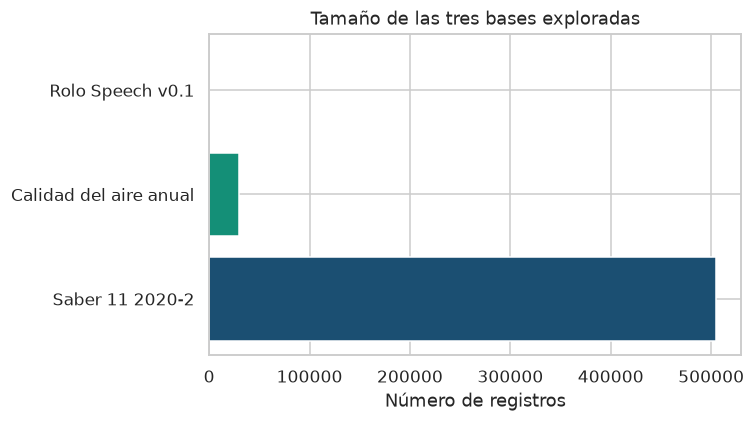

In [7]:
resumen = FIG / "01_tamano_bases.png"
fig, ax = plt.subplots(figsize=(7, 4))
ax.barh(comparacion["Base"], comparacion["Registros"], color=["#1b4f72", "#148f77", "#b9770e"])
ax.set_xlabel("Número de registros")
ax.set_title("Tamaño de las tres bases exploradas")
fig.tight_layout()
fig.savefig(resumen, bbox_inches="tight")
plt.show()


In [8]:
def tabla_md(frame):
    columnas = list(frame.columns)
    lineas = [
        "| " + " | ".join(columnas) + " |",
        "| " + " | ".join("---" for _ in columnas) + " |",
    ]
    for _, fila_tabla in frame.iterrows():
        lineas.append("| " + " | ".join(str(fila_tabla[c]) for c in columnas) + " |")
    return "\n".join(lineas)

texto = f"""# Comparación de bases y elección

Exploración hecha sobre los archivos descargados, no sobre la ficha del portal.

{tabla_md(comparacion)}

## Criterios

- **Completitud.** Saber 11 tiene faltantes reales en el cuestionario (sobre todo `COLE_BILINGUE` y el bloque familiar, cerca del 3 %). El aire está casi completo, así que deja poco que decidir sobre imputación. Rolo Speech está completo, pero es un solo hablante.
- **Relevancia.** Saber 11 permite hipótesis sobre estrato, educación de la madre, naturaleza del colegio y puntaje. El aire sirve para medio ambiente, aunque cada fila ya es un promedio anual. El audio no trae las variables que el EDA del curso pide contrastar.
- **Documentación.** Las dos tabulares tienen ficha pública en datos.gov.co. Rolo Speech tiene tarjeta de dataset y licencia, suficiente para descartarla con criterio y corta para un análisis largo.
- **Manejabilidad.** Saber 11 pesa {tamano_mb(RAW / "saber11_2020_2.csv"):.0f} MB y abre en pandas. El aire es más liviano ({tamano_mb(RAW / "calidad_aire_anual.csv"):.1f} MB). El audio cabe en disco, pero el trabajo posterior (IQR, chi-cuadrado, PCA de atributos) no es su análisis natural.

## Elección

**Saber 11, calendario A, periodo 2020-2.**

Es la base que deja hacer las tres fases con datos colombianos: hay categóricas y numéricas, faltantes que hay que justificar, puntajes donde se puede discutir si un valor extremo se conserva, y bastantes filas para una prueba estadística con tamaño del efecto. El archivo histórico 2010-2022 (más de 7 millones de filas) se deja por fuera por tamaño. El aire queda como segunda opción si el equipo prefiere medio ambiente. Rolo Speech cumple el segundo tipo de dato y no se elige como base final.
"""
destino = ROOT / "01_exploracion" / "comparacion.md"
destino.write_text(texto, encoding="utf-8")
print(destino)
print(texto)


/home/harol/develop/personal/repos/entregable-eda-analisis-datos-2026-2/01_exploracion/comparacion.md
# Comparación de bases y elección

Exploración hecha sobre los archivos descargados, no sobre la ficha del portal.

| Base | Tipo de dato | Origen para el equipo | Registros | Atributos | Tamaño (MB) | Faltantes | Documentación | Uso posible |
| --- | --- | --- | --- | --- | --- | --- | --- | --- |
| Saber 11 2020-2 | Tabular | Secundaria | 504872 | 81 | 373.5 | 40 columnas; celda vacía promedio 1.27% | Ficha en datos.gov.co e ICFES | Relación entre contexto del estudiante y puntaje |
| Calidad del aire anual | Tabular | Secundaria | 29683 | 28 | 8.5 | celda vacía promedio 0.02% | Ficha IDEAM en datos.gov.co | Comparar contaminantes entre estaciones y años |
| Rolo Speech v0.1 | Audio | Secundaria (primaria para quien grabó) | 220 | 6 | 29.4 | sin transcripciones vacías | Tarjeta de Hugging Face y licencia CC BY-NC-SA 4.0 | Reconocimiento de voz de un acento; no el EDA tabular del curs